In [30]:
import sys
import os

# Go up one level from notebooks/ to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

print("Project root:", project_root)
print("Python path:", sys.path[0])

Project root: /Users/siddharthagrawal/Desktop/solar_forecast_platform
Python path: /Users/siddharthagrawal/Desktop/solar_forecast_platform


In [31]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

# Verify file exists
path = os.path.join(project_root, 'src', 'optimization', 'battery_optimizer.py')
print("File exists:", os.path.exists(path))

File exists: True


In [32]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle



# Load your feature data
df = pd.read_parquet('/Users/siddharthagrawal/Desktop/solar_forecast_platform/data/processed/jaipur_features_90d.parquet')


# Load XGBoost model
with open('/Users/siddharthagrawal/Desktop/solar_forecast_platform/notebooks/src/models/xgboost_solar_v2.pkl', 'rb') as f:
    model_xgb = pickle.load(f)

# Get test set forecast
feature_cols = [
    'shortwave_radiation', 'cloud_cover', 'temperature_2m',
    'relative_humidity_2m', 'wind_speed_10m',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'solar_lag_1h', 'solar_lag_24h', 'solar_lag_48h',
    'solar_lag_168h', 'solar_rolling_mean_3h',
    'solar_rolling_mean_6h', 'solar_rolling_std_3h',
    'clear_sky_ratio'
]

n = len(df)
test_start = int(n * 0.85)
test = df.iloc[test_start:]

X_test = test[feature_cols]
# Align feature names/order with what the trained XGBoost model expects
expected_cols = model_xgb.get_booster().feature_names

# Fallback if feature names were not saved with the model
if expected_cols is None:
    expected_cols = list(X_test.columns)

# Rename only if model expects space-separated names
rename_map = {}
if 'hour sin' in expected_cols:
    rename_map['hour_sin'] = 'hour sin'
if 'hour cos' in expected_cols:
    rename_map['hour_cos'] = 'hour cos'
if 'month sin' in expected_cols:
    rename_map['month_sin'] = 'month sin'
if 'month cos' in expected_cols:
    rename_map['month_cos'] = 'month cos'

X_test_aligned = X_test.rename(columns=rename_map).copy()

# Add any missing expected columns safely
for col in expected_cols:
    if col not in X_test_aligned.columns:
        X_test_aligned[col] = 0.0

# Keep exact order expected by the model
X_test_aligned = X_test_aligned[expected_cols].fillna(0.0)

solar_forecast = model_xgb.predict(X_test_aligned)

# Simulate realistic demand
# Jaipur demand: base 40 MW + morning/evening peaks
hours = test.index.hour
demand_forecast = (
    40 +
    10 * np.sin(np.pi * (hours - 6) / 12) +
    np.random.normal(0, 2, len(hours))
)
demand_forecast = np.clip(demand_forecast, 30, 65)

print("Solar forecast range:",
      solar_forecast.min().round(1),
      "to", solar_forecast.max().round(1), "MW")
print(
    "Demand forecast range:",
    round(float(np.min(demand_forecast)), 1),
    "to",
    round(float(np.max(demand_forecast)), 1),
    "MW"
)
print("Hours to optimize:", len(solar_forecast))

Solar forecast range: -0.0 to 60.6 MW
Demand forecast range: 30.0 to 54.3 MW
Hours to optimize: 299


In [33]:
from src.optimization.battery_optimizer import BatteryOptimizer

optimizer = BatteryOptimizer(
    battery_capacity_mwh=50,
    charge_rate_mw=25,
    discharge_rate_mw=25,
    initial_charge_mwh=25
)

# Run on first 7 days (168 hours)
results = optimizer.optimize(
    solar_forecast=solar_forecast[:168],
    demand_forecast=demand_forecast[:168]
)

print("\nFirst 12 hours of decisions:")
print(results.head(12).to_string())

2026-06-16 02:24:34.692 | INFO     | src.optimization.battery_optimizer:__init__:26 - BatteryOptimizer initialised: capacity=50MWh, charge_rate=25MW
2026-06-16 02:24:34.693 | INFO     | src.optimization.battery_optimizer:optimize:41 - Optimizing 168-hour dispatch schedule
2026-06-16 02:24:35.857 | INFO     | src.optimization.battery_optimizer:optimize:114 - Optimization status: Optimal



First 12 hours of decisions:
    solar_mw  demand_mw  surplus_mw  charge_mw  discharge_mw  battery_level_mwh  grid_balance_mw     action
0      59.49      50.76        8.73       8.73          0.00              33.73             0.00     CHARGE
1      56.01      51.22        4.79       4.79          0.00              38.52            -0.00     CHARGE
2      49.15      45.72        3.43       3.43          0.00              41.95             0.00     CHARGE
3      35.76      46.41      -10.65       0.00         10.65              31.30            -0.00  DISCHARGE
4      24.81      39.60      -14.79       0.00         14.79              16.51             0.00  DISCHARGE
5       8.83      41.79      -32.96       0.00          0.00              16.51           -32.96       HOLD
6       0.01      38.52      -38.51       0.00          0.00              16.51           -38.51       HOLD
7      -0.00      34.58      -34.58       0.00          0.00              16.51           -34.58       HOL

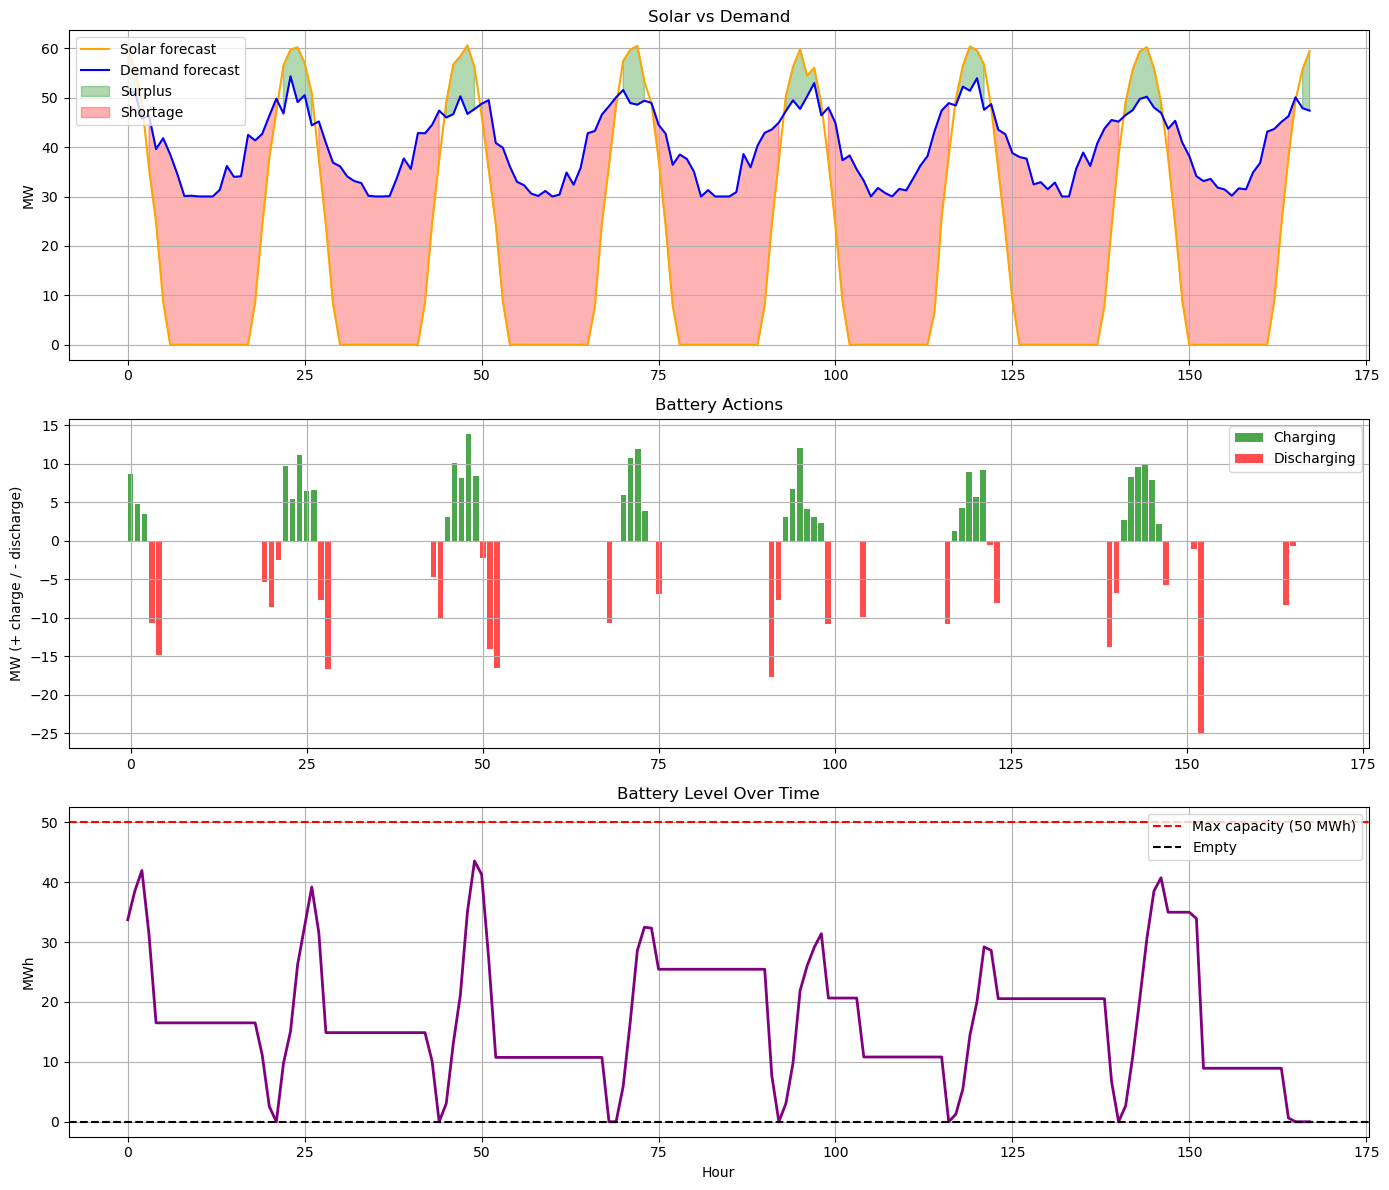

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Chart 1 — Solar vs Demand
axes[0].plot(results['solar_mw'],
             label='Solar forecast', color='orange')
axes[0].plot(results['demand_mw'],
             label='Demand forecast', color='blue')
axes[0].fill_between(
    range(len(results)),
    results['solar_mw'],
    results['demand_mw'],
    where=results['solar_mw'] > results['demand_mw'],
    alpha=0.3, color='green', label='Surplus'
)
axes[0].fill_between(
    range(len(results)),
    results['solar_mw'],
    results['demand_mw'],
    where=results['solar_mw'] < results['demand_mw'],
    alpha=0.3, color='red', label='Shortage'
)
axes[0].set_title('Solar vs Demand')
axes[0].set_ylabel('MW')
axes[0].legend()
axes[0].grid(True)

# Chart 2 — Battery charge/discharge
axes[1].bar(range(len(results)),
            results['charge_mw'],
            label='Charging', color='green', alpha=0.7)
axes[1].bar(range(len(results)),
            -results['discharge_mw'],
            label='Discharging', color='red', alpha=0.7)
axes[1].set_title('Battery Actions')
axes[1].set_ylabel('MW (+ charge / - discharge)')
axes[1].legend()
axes[1].grid(True)

# Chart 3 — Battery level over time
axes[2].plot(results['battery_level_mwh'],
             color='purple', linewidth=2)
axes[2].axhline(y=50, color='red', linestyle='--',
                label='Max capacity (50 MWh)')
axes[2].axhline(y=0, color='black', linestyle='--',
                label='Empty')
axes[2].set_title('Battery Level Over Time')
axes[2].set_ylabel('MWh')
axes[2].set_xlabel('Hour')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()